In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.preprocessing import *

In [24]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                17986 non-null  object 
 1   Close               17986 non-null  float64
 2   Ticker              17986 non-null  object 
 3   Monthly_Return      17514 non-null  float64
 4   Monthly_Variance    17514 non-null  float64
 5   Market_Covariance   17514 non-null  float64
 6   MarketCap           17935 non-null  float64
 7   EnterpriseValue     17935 non-null  float64
 8   PE_Trailing         17896 non-null  float64
 9   EnterpriseToEbitda  17935 non-null  float64
 10  PriceToBook         17896 non-null  float64
 11  operatingMargins    17986 non-null  float64
 12  profitMargins       17947 non-null  float64
 13  returnOnEquity      17908 non-null  float64
 14  ReturnOnAssets      17947 non-null  float64
 15  debtToEquity        17947 non-null  float64
 16  curr

In [25]:
columnas_a_eliminar = ['Close']
df.drop(columnas_a_eliminar, axis=1, inplace=True)

# Formatear market cap y EnterpriseValue en billions
df["MarketCap"] = df["MarketCap"] / 10**9
df["EnterpriseValue"] = df["EnterpriseValue"] / 10**9

# Variables continuas

In [26]:
# Distribucion de variables continuas
df.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,17514.0,0.0145,0.0962,-0.5197,-0.0414,0.0109,0.0627,1.4275
Monthly_Variance,17514.0,0.0088,0.0140,0.0006,0.0036,0.0059,0.0098,0.3652
Market_Covariance,17514.0,0.0016,0.0015,-0.0040,0.0006,0.0014,0.0024,0.0170
MarketCap,17935.0,108.0204,348.7979,0.6997,18.2065,35.0400,76.7371,5137.1721
EnterpriseValue,17935.0,120.0848,353.2298,3.1643,22.7944,43.6037,90.5237,5137.6071
PE_Trailing,17896.0,-15.3395,1987.5690,-101202.9506,15.5357,24.2741,36.3376,5658.6473
EnterpriseToEbitda,17935.0,22.6847,90.9201,-1813.3252,11.0840,15.7821,21.9952,3204.6996
PriceToBook,17896.0,6.8832,52.6812,-1113.1821,1.8718,3.7384,8.0771,1353.0636
operatingMargins,17986.0,0.1910,0.1513,-1.5994,0.1065,0.1775,0.2613,0.9260
profitMargins,17947.0,0.1335,0.1556,-1.7235,0.0671,0.1213,0.1979,1.0399


In [27]:
# Coeficientes de asimetría
df.select_dtypes(include="number").skew()

Monthly_Return         1.521220
Monthly_Variance      11.980931
Market_Covariance      1.343333
MarketCap              8.258320
EnterpriseValue        8.120426
PE_Trailing          -39.313660
EnterpriseToEbitda    13.531623
PriceToBook            6.937696
operatingMargins      -0.439499
profitMargins         -1.904024
returnOnEquity         0.731541
ReturnOnAssets         0.714233
debtToEquity          -4.318166
currentRatio           6.739266
Revenue_YoY            3.571799
Revenue_QoQ            8.061516
EBITDA_YoY           -11.833960
EBITDA_QoQ           -24.458847
FCF_YoY               22.331290
FCF_QoQ               45.077450
Capex_YoY            -31.803654
Capex_QoQ            -69.865404
NetDebt_to_EBITDA      5.963160
FCF_to_EBITDA         13.963776
Capex_to_Revenue       2.862474
FedFundsRate          -0.717116
UnemploymentRate      -0.341588
10Y2YSpread           -0.234983
HighYieldSpread        0.912775
CPI_QoQ                0.655326
CPI_YoY                0.254269
M2_QoQ  

Cont


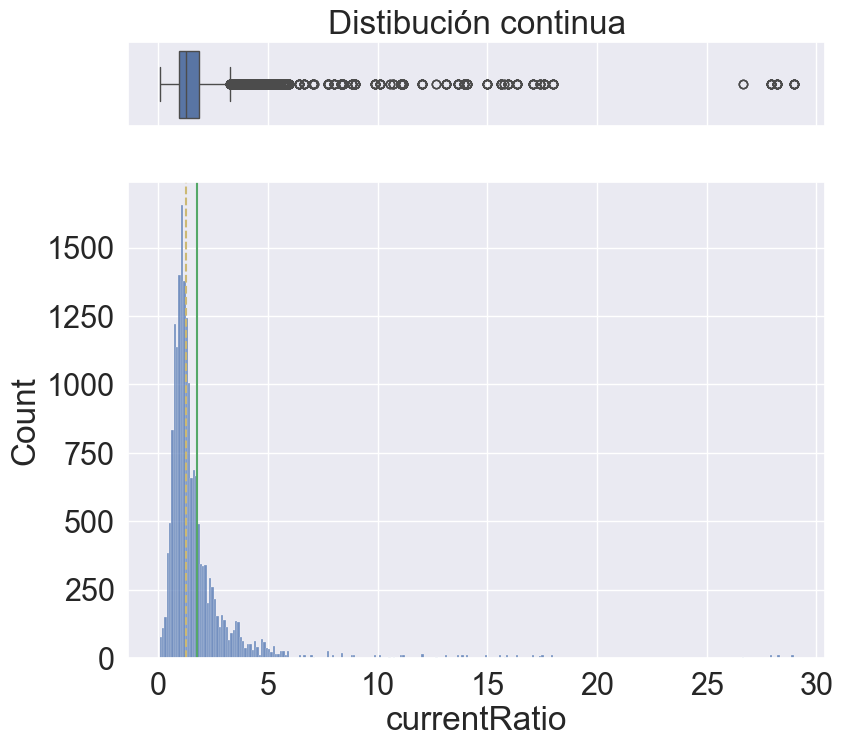

In [28]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df[columna_a_graficar])

In [29]:
# Transformacion yeo-johnson sobre ratios de valuación
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'PE_Trailing', 'EnterpriseToEbitda']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

In [30]:
# Transformaciones logarítmicas
columnas_a_transformar = ['MarketCap', 'EnterpriseValue', 'debtToEquity', 'currentRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

c:\Users\sebas\anaconda3\envs\ucm-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Monthly_Return                     1.521220
Monthly_Variance                  11.980931
Market_Covariance                  1.343333
operatingMargins                  -0.439499
profitMargins                     -1.904024
ReturnOnAssets                     0.714233
Revenue_YoY                        3.571799
Revenue_QoQ                        8.061516
EBITDA_YoY                       -11.833960
EBITDA_QoQ                       -24.458847
FCF_YoY                           22.331290
FCF_QoQ                           45.077450
Capex_YoY                        -31.803654
Capex_QoQ                        -69.865404
NetDebt_to_EBITDA                  5.963160
FCF_to_EBITDA                     13.963776
Capex_to_Revenue                   2.862474
FedFundsRate                      -0.717116
UnemploymentRate                  -0.341588
10Y2YSpread                       -0.234983
HighYieldSpread                    0.912775
CPI_QoQ                            0.655326
CPI_YoY                         

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [31]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Monthly_Return
Monthly_Variance
Market_Covariance
operatingMargins
profitMargins
ReturnOnAssets
Revenue_YoY
Revenue_QoQ
EBITDA_YoY
EBITDA_QoQ
FCF_YoY
FCF_QoQ
Capex_YoY
Capex_QoQ
NetDebt_to_EBITDA
FCF_to_EBITDA
Capex_to_Revenue
FedFundsRate
UnemploymentRate
10Y2YSpread
HighYieldSpread
CPI_QoQ
CPI_YoY
M2_QoQ
M2_YoY
PriceToBook_Transformed
returnOnEquity_Transformed
PE_Trailing_Transformed
EnterpriseToEbitda_Transformed
MarketCap_log
EnterpriseValue_log
debtToEquity_log
currentRatio_log


In [32]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Monthly_Return                    0.453039
Monthly_Variance                  1.759442
Market_Covariance                 1.038091
operatingMargins                  0.528254
profitMargins                     0.152278
ReturnOnAssets                    0.579405
Revenue_YoY                       0.208168
Revenue_QoQ                      -2.258950
EBITDA_YoY                        0.454568
EBITDA_QoQ                       -0.500992
FCF_YoY                           0.451426
FCF_QoQ                           1.689003
Capex_YoY                        -1.042864
Capex_QoQ                         2.485486
NetDebt_to_EBITDA                 0.385370
FCF_to_EBITDA                    -0.243943
Capex_to_Revenue                  1.664236
FedFundsRate                     -0.717116
UnemploymentRate                 -0.341588
10Y2YSpread                      -0.234983
HighYieldSpread                   0.912775
CPI_QoQ                           0.655326
CPI_YoY                           0.254269
M2_QoQ     

Cont


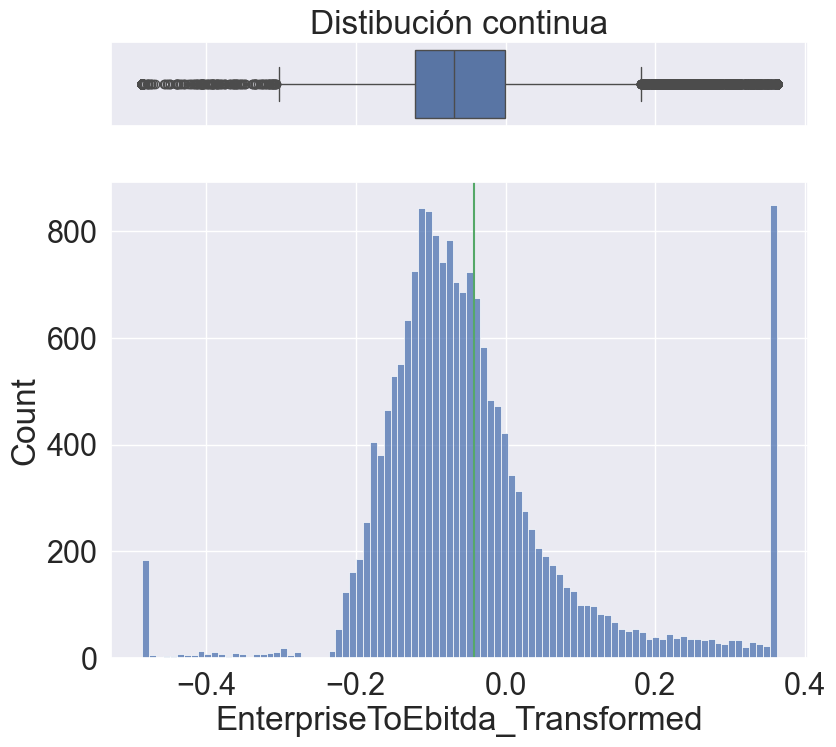

In [33]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda_Transformed' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [34]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,17514.0,1.346322e-02,0.089984,-0.356837,-0.041419,0.010946,0.062688,0.375544
Monthly_Variance,17514.0,7.812051e-03,0.006224,0.000622,0.003584,0.005857,0.009780,0.028417
Market_Covariance,17514.0,1.637857e-03,0.001497,-0.003955,0.000618,0.001377,0.002409,0.007783
operatingMargins,17986.0,1.918540e-01,0.140423,-0.359800,0.106500,0.177500,0.261300,0.741900
profitMargins,17947.0,1.360661e-01,0.129918,-0.353200,0.067100,0.121300,0.197900,0.603100
ReturnOnAssets,17947.0,7.939637e-02,0.077143,-0.227700,0.033000,0.063500,0.117400,0.388700
Revenue_YoY,12549.0,5.240908e-02,0.127215,-0.328167,-0.002829,0.048265,0.105286,0.439850
Revenue_QoQ,16624.0,1.814320e-07,0.000016,-0.000056,0.000000,0.000000,0.000000,0.000020
EBITDA_YoY,12549.0,1.031229e-01,0.355743,-0.852690,-0.048352,0.076013,0.214375,1.002882
EBITDA_QoQ,16624.0,1.335755e-05,0.000130,-0.000320,0.000000,0.000000,0.000000,0.000237


# Variables Categoricas

In [35]:
df_non_numeric = df.select_dtypes(exclude='number')

# Valores únicos
df_non_numeric.nunique()

Date          48
Ticker       454
Sector        11
DateAdded    338
dtype: int64

In [36]:
# Convertir Sector a category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')

# Valores unicos en Sector
df_non_numeric['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2828
HealthCare               2200
ConsumerDiscretionary    1900
ConsumerStaples          1477
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    857
Name: count, dtype: int64

In [37]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_non_numeric['DateAdded'] = pd.to_datetime(df_non_numeric['DateAdded'], errors='coerce')
df_non_numeric['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_non_numeric['DateAdded']).dt.days / 365.25), 0)
df_non_numeric.drop('DateAdded', axis=1, inplace=True)

In [38]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Date,Ticker,Sector,YearsSinceAdded,Monthly_Return,Monthly_Variance,Market_Covariance,operatingMargins,profitMargins,ReturnOnAssets,...,M2_QoQ,M2_YoY,PriceToBook_Transformed,returnOnEquity_Transformed,PE_Trailing_Transformed,EnterpriseToEbitda_Transformed,MarketCap_log,EnterpriseValue_log,debtToEquity_log,currentRatio_log
0,2023-01-01,A,HealthCare,26.0,NaN,NaN,NaN,0.2363,0.1831,0.1191,...,-0.010708,NaN,0.037637,0.013794,-0.038175,0.023661,3.814929,3.852051,0.420025,1.108596
1,2023-02-01,A,HealthCare,26.0,NaN,NaN,NaN,0.2363,0.1831,0.1191,...,-0.011399,NaN,0.027140,0.013794,-0.044473,0.006620,3.747707,3.787359,0.420025,1.108596
2,2023-03-01,A,HealthCare,26.0,NaN,NaN,NaN,0.2363,0.1831,0.1191,...,-0.008485,NaN,0.023370,0.013794,-0.046716,0.000497,3.722424,3.763071,0.420025,1.108596
3,2023-04-01,A,HealthCare,26.0,-0.021035,0.005672,0.003620,0.2363,0.1831,0.1191,...,-0.007643,NaN,0.020345,0.013794,-0.048508,-0.004414,3.701684,3.743165,0.420025,1.108596
4,2023-05-01,A,HealthCare,26.0,-0.144514,0.007249,0.003212,0.2363,0.1831,0.1191,...,-0.016166,NaN,-0.000012,0.013794,-0.060381,-0.037480,3.549758,3.597885,0.420025,1.108596


# Missings

In [39]:
df_combined.isnull().sum()

Date                                 0
Ticker                               0
Sector                               0
YearsSinceAdded                      0
Monthly_Return                     472
Monthly_Variance                   472
Market_Covariance                  472
operatingMargins                     0
profitMargins                       39
ReturnOnAssets                      39
Revenue_YoY                       5437
Revenue_QoQ                       1362
EBITDA_YoY                        5437
EBITDA_QoQ                        1362
FCF_YoY                           5437
FCF_QoQ                           1362
Capex_YoY                         5653
Capex_QoQ                         1650
NetDebt_to_EBITDA                   39
FCF_to_EBITDA                        0
Capex_to_Revenue                   312
FedFundsRate                         3
UnemploymentRate                   456
10Y2YSpread                          3
HighYieldSpread                   2208
CPI_QoQ                  

In [40]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [41]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YearsSinceAdded                 17986 non-null  float64
 1   Monthly_Return                  17986 non-null  float64
 2   Monthly_Variance                17986 non-null  float64
 3   Market_Covariance               17986 non-null  float64
 4   operatingMargins                17986 non-null  float64
 5   profitMargins                   17986 non-null  float64
 6   ReturnOnAssets                  17986 non-null  float64
 7   Revenue_YoY                     17986 non-null  float64
 8   Revenue_QoQ                     17986 non-null  float64
 9   EBITDA_YoY                      17986 non-null  float64
 10  EBITDA_QoQ                      17986 non-null  float64
 11  FCF_YoY                         17986 non-null  float64
 12  FCF_QoQ                         

In [42]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   YearsSinceAdded                 17986 non-null  float64 
 1   Monthly_Return                  17986 non-null  float64 
 2   Monthly_Variance                17986 non-null  float64 
 3   Market_Covariance               17986 non-null  float64 
 4   operatingMargins                17986 non-null  float64 
 5   profitMargins                   17986 non-null  float64 
 6   ReturnOnAssets                  17986 non-null  float64 
 7   Revenue_YoY                     17986 non-null  float64 
 8   Revenue_QoQ                     17986 non-null  float64 
 9   EBITDA_YoY                      17986 non-null  float64 
 10  EBITDA_QoQ                      17986 non-null  float64 
 11  FCF_YoY                         17986 non-null  float64 
 12  FCF_QoQ           

In [43]:
df_final.select_dtypes(include='number').skew()

YearsSinceAdded                   1.035380
Monthly_Return                    0.486023
Monthly_Variance                  1.729018
Market_Covariance                 0.950606
operatingMargins                  0.528254
profitMargins                     0.147744
ReturnOnAssets                    0.574233
Revenue_YoY                       0.204311
Revenue_QoQ                      -2.353068
EBITDA_YoY                        0.622450
EBITDA_QoQ                       -0.493855
FCF_YoY                           0.692990
FCF_QoQ                           1.782582
Capex_YoY                        -0.916701
Capex_QoQ                         2.622476
NetDebt_to_EBITDA                 0.383567
FCF_to_EBITDA                    -0.243943
Capex_to_Revenue                  1.661385
FedFundsRate                     -0.717165
UnemploymentRate                 -0.384077
10Y2YSpread                      -0.234998
HighYieldSpread                   1.081129
CPI_QoQ                           0.710838
CPI_YoY    

In [44]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")